# V12.1: Streamlined Spectral Sparsity — Beat GPT-Nano

## Changes from V12

| Change | V12 | V12.1 | Why |
|--------|-----|-------|-----|
| Langevin steps | 5 | 2 | Ramsauer 2021: single-step Hopfield ≈ softmax attention. 5 steps → diminishing returns. |
| Memory routing | 8 MLP routers (165K/block) | Dot-product Hopfield (0 extra params) | Router learns what dot-product already computes |
| Channel mixing | None | SpatialMLP per block | GPT has attention+MLP; V12 had no MLP. The missing nonlinearity. |
| Depth | 4 blocks | 6 blocks | More representational depth, still under GPT's param count |
| Context dim | 256 | 128 | Saves params for MLP + more blocks |
| Spectral sparsity | 8/32 (25%) | 10/32 (31%) | V12 measured ~60% sparsity — model wanted more active modes |
| Training steps | 5,000 | 10,000 | V12 was still improving at 5K |

## Non-Negotiables (Preserved)

1. Sparse in spectral, dense only transiently in spatial
2. Field reconstruction IS the IFFT
3. Langevin starts from the reconstructed (IFFT) field
4. Context warps the spectral metric (D, A context-dependent)
5. Spectral proximal at every Langevin step
6. Subbundles are independent spectral channels
7. No pairwise token attention

## Key Paper Justifications

- **Ramsauer 2021**: Hopfield retrieval = softmax attention (justifies 5→2 step reduction)
- **Associative Transformer 2023**: Explicit Hopfield memory + fewer params outperforms sparse transformers
- **Santos 2024**: Sparse Hopfield gives exact retrieval with exponential capacity
- **V17 CLS thesis**: Memory and computation co-evolving from scratch is the right paradigm

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import math
import time
import os

# Device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device: {device}")

# Data
DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATA_PATH = os.path.join(os.getcwd(), "tiny_shakespeare.txt")

if not os.path.exists(DATA_PATH):
    print("Downloading Tiny Shakespeare...")
    import urllib.request
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

with open(DATA_PATH, "r") as f:
    text = f.read()

chars = sorted(set(text))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}

data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
split = int(0.9 * len(data))
train_data = data[:split]
val_data = data[split:]

print(f"Tiny Shakespeare: {len(data):,} chars, vocab {vocab_size}")
print(f"Train: {len(train_data):,} | Val: {len(val_data):,}")

Device: mps
Tiny Shakespeare: 1,115,394 chars, vocab 65
Train: 1,003,854 | Val: 111,540


In [ ]:
@dataclass
class V12_1Config:
    # Fiber geometry
    fiber_dim: int = 256
    n_subbundles: int = 8
    spectral_sparsity: int = 10      # s_k: active spectral modes per subbundle (was 8)

    # Vocabulary
    vocab_size: int = 65
    max_seq_len: int = 128

    # Architecture
    n_blocks: int = 6                # was 4
    context_dim: int = 128           # was 256
    atoms_per_subbundle: int = 16    # was 32
    mlp_ratio: float = 1.5           # MLP hidden = fiber_dim * mlp_ratio = 384

    # Langevin settling
    langevin_steps: int = 3          # was 5
    langevin_lr: float = 0.03
    beta_init: float = 4.0           # was 1.0
    beta_final: float = 12.0

    # Training — trapezoidal LR: warmup -> hold at peak -> cosine decay
    learning_rate: float = 7e-3      # restored from V12 (was 5e-3)
    min_lr: float = 7e-4             # cosine floor (was 0)
    warmup_steps: int = 750
    lr_hold_steps: int = 3250        # hold at peak LR until step 4000 (40% of training)
    dropout: float = 0.1
    batch_size: int = 32
    seq_len: int = 256
    max_steps: int = 10000           # was 5000
    eval_interval: int = 500
    eval_steps: int = 10

    @property
    def subbundle_dim(self):
        return self.fiber_dim // self.n_subbundles

    @property
    def total_active_modes(self):
        return self.n_subbundles * self.spectral_sparsity

    @property
    def mlp_hidden(self):
        return int(self.fiber_dim * self.mlp_ratio)


config = V12_1Config(vocab_size=vocab_size)
print(f"Fiber: {config.fiber_dim} = {config.n_subbundles} x {config.subbundle_dim}")
print(f"Spectral sparsity: {config.spectral_sparsity}/{config.subbundle_dim} modes per subbundle "
      f"= {100*config.spectral_sparsity/config.subbundle_dim:.0f}% active "
      f"({config.total_active_modes}/{config.fiber_dim} total)")
print(f"Blocks: {config.n_blocks}, Context dim: {config.context_dim}")
print(f"MLP hidden: {config.mlp_hidden}")
print(f"Langevin steps: {config.langevin_steps}, beta: {config.beta_init} -> {config.beta_final}")
print(f"Atoms: {config.atoms_per_subbundle} per subbundle")
decay_start = config.warmup_steps + config.lr_hold_steps
print(f"LR: warmup 0->{config.learning_rate} (0-{config.warmup_steps}), "
      f"hold ({config.warmup_steps}-{decay_start}), "
      f"cosine -> {config.min_lr} ({decay_start}-{config.max_steps})")
print(f"Batch: {config.batch_size}, Seq: {config.seq_len}, Steps: {config.max_steps}")

def get_batch(split_data, cfg):
    max_start = len(split_data) - cfg.seq_len - 1
    starts = torch.randint(0, max_start, (cfg.batch_size,))
    return torch.stack([split_data[s:s+cfg.seq_len] for s in starts]).to(device)

Fiber: 256 = 8 x 32
Spectral sparsity: 10/32 modes per subbundle = 31% active (80/256 total)
Blocks: 6, Context dim: 128
MLP hidden: 384
Langevin steps: 3, beta: 4.0 -> 12.0
Atoms: 16 per subbundle
LR: warmup 0->0.007 (0-750), hold (750-4000), cosine -> 0.0001 (4000-10000)
Batch: 32, Seq: 256, Steps: 10000


## V12.1 Architecture Modules

Key innovation over V12: **SpatialMLP** provides the nonlinear channel mixing that
GPT gets from its FFN. Memory routing simplified to direct dot-product Hopfield
(Ramsauer 2021). Langevin reduced to 2 steps with spectral proximal at each.

In [3]:
# -- Shared utilities -------------------------------------------------------

def spectral_sparsify(x_complex, cfg):
    """Per-subbundle top-s_k sparsification in spectral domain.
    Uses pairwise comparison instead of torch.topk -- 49x faster on MPS.
    Mask computed under no_grad; gradients flow through selected values only."""
    shape = x_complex.shape
    x_subs = x_complex.reshape(*shape[:-1], cfg.n_subbundles, cfg.subbundle_dim)
    with torch.no_grad():
        mags = x_subs.abs()
        gt_count = (mags.unsqueeze(-1) < mags.unsqueeze(-2)).sum(dim=-1)
        mask = (gt_count < cfg.spectral_sparsity).float()
    return (x_subs * mask).reshape(shape)


def spectral_to_spatial(x_spectral, cfg):
    """IFFT per subbundle: sparse spectral -> dense spatial (real)."""
    shape = x_spectral.shape
    subs = x_spectral.reshape(*shape[:-1], cfg.n_subbundles, cfg.subbundle_dim)
    spatial = torch.fft.ifft(subs, dim=-1).real
    return spatial.reshape(*shape[:-1], cfg.fiber_dim)


def spatial_to_spectral(x_spatial, cfg):
    """FFT per subbundle: dense spatial -> spectral (complex)."""
    shape = x_spatial.shape
    subs = x_spatial.reshape(*shape[:-1], cfg.n_subbundles, cfg.subbundle_dim)
    spectral = torch.fft.fft(subs, dim=-1)
    return spectral.reshape(*shape[:-1], cfg.fiber_dim)


def spectral_proximal(x_spatial, cfg):
    """V12 proximal operator: FFT -> top-s_k per subbundle -> IFFT.
    Enforces spectral sparsity while operating on spatial state."""
    x_spec = spatial_to_spectral(x_spatial, cfg)
    x_sparse = spectral_sparsify(x_spec, cfg)
    return spectral_to_spatial(x_sparse, cfg)


def parallel_associative_scan(A, B):
    """O(log T) Hillis-Steele parallel scan: q_t = A_t * q_{t-1} + B_t."""
    _, T, _ = A.shape
    a, b = A, B
    for d in range(int(math.ceil(math.log2(T)))):
        step = 2 ** d
        if step >= T:
            break
        b = torch.cat([b[:, :step, :],
                        a[:, step:, :] * b[:, :-step, :] + b[:, step:, :]], dim=1)
        a = torch.cat([a[:, :step, :],
                        a[:, step:, :] * a[:, :-step, :]], dim=1)
    return b


print("Utilities defined: spectral_sparsify (pairwise, no topk),\n"
      "  spectral_to_spatial, spatial_to_spectral, spectral_proximal,\n"
      "  parallel_associative_scan (O(log T) Hillis-Steele)")

Utilities defined: spectral_sparsify (pairwise, no topk),
  spectral_to_spatial, spatial_to_spectral, spectral_proximal,
  parallel_associative_scan (O(log T) Hillis-Steele)


In [4]:
# -- Spectral Token Embedding -----------------------------------------------

class SpectralTokenEmbedding(nn.Module):
    """Tokens as sparse spectral configurations.
    Magnitude embedding + learned phase + positional phase -> complex spectral -> sparsify."""

    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.mag_embedding = nn.Embedding(cfg.vocab_size, cfg.fiber_dim)
        self.phase_embedding = nn.Embedding(cfg.vocab_size, cfg.fiber_dim)
        nn.init.uniform_(self.phase_embedding.weight, -math.pi, math.pi)

        freqs = torch.zeros(cfg.fiber_dim)
        for k in range(cfg.n_subbundles):
            offset = k * cfg.subbundle_dim
            freqs[offset:offset + cfg.subbundle_dim] = (
                2 * math.pi * torch.arange(cfg.subbundle_dim).float() / cfg.subbundle_dim
            )
        self.register_buffer("freqs", freqs)

    def forward(self, token_ids):
        B, T = token_ids.shape
        mag = self.mag_embedding(token_ids)
        phase_offset = self.phase_embedding(token_ids)
        positions = torch.arange(T, device=token_ids.device).float()
        pos_phase = positions.unsqueeze(-1) * self.freqs.unsqueeze(0)
        total_phase = phase_offset + pos_phase.unsqueeze(0)
        spectral = mag * torch.exp(1j * total_phase)
        return spectral_sparsify(spectral, self.cfg)

In [5]:
# -- Context Accumulator (SSM) ----------------------------------------------

class ContextAccumulator(nn.Module):
    """Content-dependent SSM with parallel scan.
    q_t = A(x_t) * q_{t-1} + B(x_t) * psi(x_t)
    V12.1: fiber_dim -> context_dim (128, was 256)."""

    def __init__(self, cfg):
        super().__init__()
        self.A_proj = nn.Linear(cfg.fiber_dim, cfg.context_dim)
        self.B_proj = nn.Linear(cfg.fiber_dim, cfg.context_dim)
        self.psi_proj = nn.Linear(cfg.fiber_dim, cfg.context_dim)

    def forward(self, x_spatial):
        A = torch.sigmoid(self.A_proj(x_spatial))
        B = torch.sigmoid(self.B_proj(x_spatial))
        psi = self.psi_proj(x_spatial)
        return parallel_associative_scan(A, B * psi)

In [6]:
# -- Spectral Transport -----------------------------------------------------

class SpectralTransport(nn.Module):
    """Context-dependent spectral transport kernel.
    X_tilde(w) = X(w) * exp(-D(ctx)*w^2 - i*w*A(ctx))
    V12.1: context_dim=128 -> fiber_dim projections."""

    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.D_proj = nn.Linear(cfg.context_dim, cfg.fiber_dim)
        self.A_proj = nn.Linear(cfg.context_dim, cfg.fiber_dim)

    def forward(self, spectral_x, q_t):
        cfg = self.cfg
        diffusion = F.softplus(self.D_proj(q_t))
        gauge = self.A_proj(q_t)

        freqs = torch.fft.fftfreq(cfg.subbundle_dim, d=1.0, device=spectral_x.device)
        freqs = freqs.repeat(cfg.n_subbundles)
        w2 = freqs ** 2
        w = freqs

        kernel = torch.exp(-diffusion * w2 - 1j * w * gauge)
        return spectral_x * kernel

In [7]:
# -- Simplified Memory Bank -------------------------------------------------

class SimplifiedMemoryBank(nn.Module):
    """Memory atoms with direct dot-product Hopfield routing.
    No MLP routers -- sim = x_k @ M_k.T, weights = softmax(beta * sim).
    Atoms stored as spectral (real, imag), IFFT'd to spatial for comparison.
    Ramsauer 2021: this IS modern Hopfield retrieval."""

    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        sd = cfg.subbundle_dim
        K = cfg.n_subbundles
        A = cfg.atoms_per_subbundle

        self.dict_real = nn.ParameterList([
            nn.Parameter(torch.randn(A, sd) * 0.02) for _ in range(K)
        ])
        self.dict_imag = nn.ParameterList([
            nn.Parameter(torch.randn(A, sd) * 0.02) for _ in range(K)
        ])

    def get_spatial_atoms(self):
        """Pre-compute normalized spatial atoms from spectral parameters."""
        all_real = torch.stack(list(self.dict_real))   # (K, A, sd)
        all_imag = torch.stack(list(self.dict_imag))   # (K, A, sd)
        all_spatial = F.normalize(
            torch.fft.ifft(torch.complex(all_real, all_imag), dim=-1).real,
            dim=-1
        )  # (K, A, sd)
        return all_spatial

In [8]:
# -- Spectral Hopfield Settler ----------------------------------------------

class SpectralHopfieldSettler(nn.Module):
    """2-step Langevin settling with spectral proximal at every step.

    Non-negotiable #3: starts from IFFT field (dense_field).
    Non-negotiable #5: spectral proximal at every step.

    Simplified from 5 steps: beta schedule [4.0, 12.0] (explore-then-commit).
    Vectorized Hopfield gradient across all K subbundles."""

    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_inh = nn.Parameter(torch.ones(cfg.fiber_dim) * 0.01)

    def forward(self, dense_field, spatial_atoms):
        """dense_field: (B, T, D) real dense spatial.
        spatial_atoms: (K, A, sd) normalized spatial atom patterns."""
        cfg = self.cfg
        B, T, D = dense_field.shape
        sd = cfg.subbundle_dim
        K = cfg.n_subbundles
        BT = B * T

        x = dense_field  # Non-negotiable #3: init from IFFT field
        betas = torch.linspace(cfg.beta_init, cfg.beta_final, cfg.langevin_steps,
                               device=dense_field.device)

        # spatial_atoms: (K, A, sd) -> expand for batched einsum
        M_all = spatial_atoms.unsqueeze(0).expand(BT, -1, -1, -1)  # (BT, K, A, sd)

        for step in range(cfg.langevin_steps):
            beta = betas[step].item()

            # Vectorized Hopfield gradient across all K subbundles
            x_subs = x.reshape(BT, K, sd)
            sim = torch.einsum('bks,bkas->bka', x_subs, M_all)  # (BT, K, A)
            w = F.softmax(beta * sim, dim=-1)
            grad_E = -torch.einsum('bka,bkas->bks', w, M_all)   # (BT, K, sd)

            # Lateral inhibition
            inhib = self.W_inh * x

            # Langevin step
            x = x - cfg.langevin_lr * (grad_E.reshape(B, T, D) + inhib)

            # Annealing noise (eval only)
            if not self.training:
                x = x + math.sqrt(2.0 * cfg.langevin_lr / beta) * torch.randn_like(x)

            # Non-negotiable #5: spectral proximal at every step
            x = spectral_proximal(x, cfg)

        return x

In [9]:
# -- Spatial MLP (NEW in V12.1) ---------------------------------------------

class SpatialMLP(nn.Module):
    """Nonlinear channel mixing in spatial domain.
    The missing component from V12: GPT has attention + MLP, V12 had no MLP.
    Operates on transiently dense spatial representation (non-negotiable #1)."""

    def __init__(self, cfg):
        super().__init__()
        self.fc1 = nn.Linear(cfg.fiber_dim, cfg.mlp_hidden)
        self.fc2 = nn.Linear(cfg.mlp_hidden, cfg.fiber_dim)
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, x):
        return self.drop(self.fc2(F.silu(self.fc1(x))))

In [10]:
# -- V12.1 Block ------------------------------------------------------------

class V12_1Block(nn.Module):
    """One forward-reverse spectral diffusion cycle + spatial MLP.

    Flow:
    spectral -> IFFT -> SSM context -> spectral transport ->
    IFFT (field reconstruction) -> 2-step Hopfield settling ->
    SpatialMLP -> gated residual -> FFT + re-sparsify -> spectral out"""

    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.context_acc = ContextAccumulator(cfg)
        self.transport = SpectralTransport(cfg)
        self.memory = SimplifiedMemoryBank(cfg)
        self.settler = SpectralHopfieldSettler(cfg)
        self.mlp = SpatialMLP(cfg)
        self.norm1 = nn.LayerNorm(cfg.fiber_dim)
        self.norm2 = nn.LayerNorm(cfg.fiber_dim)
        self.res_gate = nn.Parameter(torch.tensor(0.5))
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, spectral_x):
        cfg = self.cfg

        # 1. Spatial projection for context accumulation
        x_spatial_in = spectral_to_spatial(spectral_x, cfg)

        # 2. Context accumulator (SSM on spatial)
        q_t = self.context_acc(x_spatial_in)

        # 3. Spectral transport (context-dependent kernel)
        transported = self.transport(spectral_x, q_t)

        # 4. Field reconstruction: IFFT -> dense spatial (non-negotiable #2)
        dense_field = spectral_to_spatial(transported, cfg)
        dense_field = self.norm1(dense_field)

        # 5. Pre-compute spatial atoms, then 2-step Hopfield settling
        spatial_atoms = self.memory.get_spatial_atoms()
        settled = self.settler(dense_field, spatial_atoms)

        # 6. Spatial MLP (NEW: nonlinear channel mixing)
        mlp_out = self.mlp(self.norm2(settled))

        # 7. Gated residual in spatial domain
        gate = torch.sigmoid(self.res_gate)
        x_spatial_out = x_spatial_in + gate * self.dropout(settled + mlp_out)

        # 8. Back to spectral and enforce sparsity (non-negotiable #1)
        spectral_out = spatial_to_spectral(x_spatial_out, cfg)
        spectral_out = spectral_sparsify(spectral_out, cfg)

        return spectral_out

In [11]:
# -- Full V12.1 Model -------------------------------------------------------

class V12_1Model(nn.Module):
    """V12.1: Streamlined Spectral Sparsity CLM.
    Selective deep supervision at blocks 2, 4, 6 (every other)."""

    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.embedding = SpectralTokenEmbedding(cfg)
        self.blocks = nn.ModuleList([V12_1Block(cfg) for _ in range(cfg.n_blocks)])
        self.final_norm = nn.LayerNorm(cfg.fiber_dim)
        self.decoder = nn.Sequential(
            nn.Linear(cfg.fiber_dim, cfg.fiber_dim), nn.SiLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.fiber_dim, cfg.vocab_size),
        )
        # Deep supervision at even-indexed blocks (1, 3, 5 = blocks 2, 4, 6)
        weights = torch.zeros(cfg.n_blocks)
        for i in range(cfg.n_blocks):
            if (i + 1) % 2 == 0:
                weights[i] = (i + 1) / cfg.n_blocks
        weights[-1] = 1.0
        self.register_buffer("block_loss_weights", weights)

    def _decode_spatial(self, spectral_x):
        spatial = spectral_to_spatial(spectral_x, self.cfg)
        return self.decoder(self.final_norm(spatial))

    def forward(self, token_ids):
        B, T = token_ids.shape
        cfg = self.cfg

        # 1. Spectral embedding
        spectral_x = self.embedding(token_ids)

        # 2. Process through blocks with selective deep supervision
        intermediate_logits = []
        for i, block in enumerate(self.blocks):
            spectral_x = block(spectral_x)
            if self.block_loss_weights[i] > 0:
                logits = self._decode_spatial(spectral_x)[:, :-1, :]
                intermediate_logits.append((logits, self.block_loss_weights[i]))

        # 3. Sparsity diagnostic
        spatial_final = spectral_to_spatial(spectral_x, cfg)
        spec_check = spatial_to_spectral(spatial_final, cfg)
        spec_sparsity = (spec_check.abs() < 1e-6).float().mean().item()

        final_logits = intermediate_logits[-1][0]
        info = {
            "spectral_sparsity": spec_sparsity,
            "intermediate_logits": intermediate_logits,
        }
        return final_logits, info


# -- Instantiate and count parameters ----------------------------------------
model = V12_1Model(config).to(device)
n_params = sum(p.numel() for p in model.parameters())
n_embed = sum(p.numel() for p in model.embedding.parameters())
n_ctx = sum(sum(p.numel() for p in blk.context_acc.parameters()) for blk in model.blocks)
n_transport = sum(sum(p.numel() for p in blk.transport.parameters()) for blk in model.blocks)
n_memory = sum(sum(p.numel() for p in blk.memory.parameters()) for blk in model.blocks)
n_settler = sum(sum(p.numel() for p in blk.settler.parameters()) for blk in model.blocks)
n_mlp = sum(sum(p.numel() for p in blk.mlp.parameters()) for blk in model.blocks)
n_decoder = sum(p.numel() for p in model.decoder.parameters()) + \
            sum(p.numel() for p in model.final_norm.parameters())
n_other = n_params - n_embed - n_ctx - n_transport - n_memory - n_settler - n_mlp - n_decoder

print(f"V12.1 Total parameters: {n_params:,}")
print(f"  Spectral Embedding:        {n_embed:,} ({100*n_embed/n_params:.1f}%)")
print(f"  Context Accumulators ({config.n_blocks}):  {n_ctx:,} ({100*n_ctx/n_params:.1f}%)")
print(f"  Spectral Transport ({config.n_blocks}):    {n_transport:,} ({100*n_transport/n_params:.1f}%)")
print(f"  Memory Banks ({config.n_blocks}):          {n_memory:,} ({100*n_memory/n_params:.1f}%)")
print(f"  Langevin Settlers ({config.n_blocks}):     {n_settler:,} ({100*n_settler/n_params:.1f}%)")
print(f"  SpatialMLP ({config.n_blocks}):            {n_mlp:,} ({100*n_mlp/n_params:.1f}%)")
print(f"  Decoder + norms:           {n_decoder:,} ({100*n_decoder/n_params:.1f}%)")
print(f"  Block norms/gates:         {n_other:,} ({100*n_other/n_params:.1f}%)")

V12.1 Total parameters: 2,345,031
  Spectral Embedding:        33,280 (1.4%)
  Context Accumulators (6):  592,128 (25.3%)
  Spectral Transport (6):    396,288 (16.9%)
  Memory Banks (6):          49,152 (2.1%)
  Langevin Settlers (6):     1,536 (0.1%)
  SpatialMLP (6):            1,183,488 (50.5%)
  Decoder + norms:           83,009 (3.5%)
  Block norms/gates:         6,150 (0.3%)


## Training

In [12]:
@torch.no_grad()
def estimate_loss(model, cfg, is_gpt=False):
    model.eval()
    results = {}
    for name, sd in [("train", train_data), ("val", val_data)]:
        tot_ce, tot_ok, tot_n, tot_sp = 0., 0, 0, 0.
        for _ in range(cfg.eval_steps):
            b = get_batch(sd, cfg)
            logits, info = model(b)
            tgt = b[:, 1:]
            ce = F.cross_entropy(logits.reshape(-1, cfg.vocab_size), tgt.reshape(-1))
            tot_ce += ce.item()
            tot_ok += (logits.argmax(-1) == tgt).sum().item()
            tot_n += tgt.numel()
            if not is_gpt:
                tot_sp += info.get("spectral_sparsity", 0.0)
        n = cfg.eval_steps
        results[name] = {
            "ce": tot_ce/n, "acc": tot_ok/tot_n,
            "sparsity": tot_sp/n if not is_gpt else 0.0,
        }
    model.train()
    return results


def train_model(model, cfg, label="V12.1", is_gpt=False):
    """Train loop for both V12.1 and GPT baseline."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=0.05)

    # Trapezoidal LR: warmup -> hold at peak -> cosine decay to min_lr
    min_ratio = getattr(cfg, 'min_lr', 0) / cfg.learning_rate
    hold_end = cfg.warmup_steps + getattr(cfg, 'lr_hold_steps', 0)

    def lr_lambda(step):
        if step < cfg.warmup_steps:
            return step / max(1, cfg.warmup_steps)
        if step < hold_end:
            return 1.0  # hold at peak
        progress = (step - hold_end) / max(1, cfg.max_steps - hold_end)
        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        return max(min_ratio, cosine)

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    history = {
        "step": [], "train_ce": [], "val_ce": [],
        "train_acc": [], "val_acc": [],
        "train_bpc": [], "val_bpc": [],
        "sparsity": [], "lr": [],
        "step_times": [], "per_step_loss": [],
    }

    model.train()
    total_start = time.time()

    print(f"\nTraining {label}: {sum(p.numel() for p in model.parameters()):,} params")
    print(f"Steps: {cfg.max_steps}, Batch: {cfg.batch_size}, Seq: {cfg.seq_len}")
    print("=" * 70)

    for step in range(cfg.max_steps + 1):
        # Eval
        if step % cfg.eval_interval == 0:
            res = estimate_loss(model, cfg, is_gpt=is_gpt)
            tr, vl = res["train"], res["val"]
            history["step"].append(step)
            history["train_ce"].append(tr["ce"])
            history["val_ce"].append(vl["ce"])
            history["train_acc"].append(tr["acc"])
            history["val_acc"].append(vl["acc"])
            history["train_bpc"].append(tr["ce"] / math.log(2))
            history["val_bpc"].append(vl["ce"] / math.log(2))
            history["sparsity"].append(vl["sparsity"])
            history["lr"].append(scheduler.get_last_lr()[0])
            sp_str = f" | Sp: {vl['sparsity']:.1%}" if not is_gpt else ""
            print(f"[{label}] Step {step:5d} | Train CE: {tr['ce']:.3f} | "
                  f"Val CE: {vl['ce']:.3f} | Val BPC: {vl['ce']/math.log(2):.2f} | "
                  f"Val Acc: {vl['acc']:.1%}{sp_str}")

        if step >= cfg.max_steps:
            break

        # Train step
        step_start = time.time()
        batch = get_batch(train_data, cfg)
        optimizer.zero_grad()

        logits, info = model(batch)
        targets = batch[:, 1:]

        if is_gpt:
            loss = F.cross_entropy(logits.reshape(-1, cfg.vocab_size), targets.reshape(-1))
        else:
            # Deep supervision: weighted sum of per-block losses
            ce_loss = 0.
            total_weight = 0.
            for block_logits, weight in info["intermediate_logits"]:
                ce_loss += weight * F.cross_entropy(
                    block_logits.reshape(-1, cfg.vocab_size), targets.reshape(-1)
                )
                total_weight += weight
            ce_loss /= total_weight

            # Dictionary coherence regularization
            dcl, nd = 0., 0
            for blk in model.blocks:
                for dr, di in zip(blk.memory.dict_real, blk.memory.dict_imag):
                    atoms = torch.fft.ifft(torch.complex(dr, di), dim=-1).real
                    An = F.normalize(atoms, dim=-1)
                    g = An @ An.T
                    dcl += (g - torch.eye(g.size(0), device=g.device)).pow(2).mean()
                    nd += 1
            dcl /= max(nd, 1)
            loss = ce_loss + 0.1 * dcl

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        history["per_step_loss"].append(loss.item())
        history["step_times"].append(time.time() - step_start)

    total_time = time.time() - total_start

    # Final summary
    print("=" * 70)
    vl_ce = history["val_ce"][-1]
    vl_acc = history["val_acc"][-1]
    print(f"[{label}] FINAL | Val CE: {vl_ce:.3f} | Val BPC: {vl_ce/math.log(2):.2f} | "
          f"Val Acc: {vl_acc:.1%}")
    print(f"[{label}] Total time: {total_time:.1f}s | "
          f"Avg step: {np.mean(history['step_times'])*1000:.1f}ms")

    history["total_time"] = total_time
    history["avg_step_ms"] = np.mean(history["step_times"]) * 1000
    return history

class GPTNano(nn.Module):
    """Minimal GPT for baseline comparison.
    Architecture: Embedding + [CausalAttention + MLP] x n_layer + LMHead"""

    def __init__(self, vocab_size=65, n_embd=128, n_head=4, n_layer=12,
                 block_size=128, dropout=0.1):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList()
        for _ in range(n_layer):
            self.blocks.append(nn.ModuleDict({
                'ln1': nn.LayerNorm(n_embd),
                'attn_qkv': nn.Linear(n_embd, 3 * n_embd),
                'attn_proj': nn.Linear(n_embd, n_embd),
                'ln2': nn.LayerNorm(n_embd),
                'mlp_fc1': nn.Linear(n_embd, 4 * n_embd),
                'mlp_fc2': nn.Linear(4 * n_embd, n_embd),
            }))

        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        self.n_head = n_head
        self.n_embd = n_embd

        causal_mask = torch.tril(torch.ones(block_size, block_size))
        self.register_buffer('causal_mask', causal_mask.view(1, 1, block_size, block_size))

    def forward(self, idx):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))

        head_dim = self.n_embd // self.n_head
        for block in self.blocks:
            h = block['ln1'](x)
            qkv = block['attn_qkv'](h).reshape(B, T, 3, self.n_head, head_dim)
            q, k, v = qkv.unbind(2)
            q, k, v = q.transpose(1, 2), k.transpose(1, 2), v.transpose(1, 2)
            att = (q @ k.transpose(-2, -1)) * (head_dim ** -0.5)
            att = att.masked_fill(self.causal_mask[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            y = (att @ v).transpose(1, 2).reshape(B, T, self.n_embd)
            x = x + block['attn_proj'](y)
            h = block['ln2'](x)
            x = x + block['mlp_fc2'](F.gelu(block['mlp_fc1'](h)))

        logits = self.lm_head(self.ln_f(x))
        return logits[:, :-1, :], {}


gpt_model = GPTNano(
    vocab_size=vocab_size, n_embd=128, n_head=4, n_layer=12,
    block_size=config.seq_len, dropout=config.dropout
).to(device)

gpt_params = sum(p.numel() for p in gpt_model.parameters())
print(f"GPT-Nano parameters: {gpt_params:,}")
print(f"V12.1 parameters:    {n_params:,}")
print(f"Ratio: GPT/V12.1 = {gpt_params/n_params:.2f}x")

GPT-Nano parameters: 2,428,928
V12.1 parameters:    2,345,031
Ratio: GPT/V12.1 = 1.04x


In [13]:
# -- Train V12.1 --
v12_history = train_model(model, config, label="V12.1", is_gpt=False)


Training V12.1: 2,345,031 params
Steps: 10000, Batch: 32, Seq: 256
[V12.1] Step     0 | Train CE: 4.196 | Val CE: 4.196 | Val BPC: 6.05 | Val Acc: 1.7% | Sp: 24.3%
[V12.1] Step   500 | Train CE: 1.544 | Val CE: 1.731 | Val BPC: 2.50 | Val Acc: 48.8% | Sp: 29.3%
[V12.1] Step  1000 | Train CE: 1.396 | Val CE: 1.618 | Val BPC: 2.33 | Val Acc: 53.0% | Sp: 44.1%
[V12.1] Step  1500 | Train CE: 1.323 | Val CE: 1.560 | Val BPC: 2.25 | Val Acc: 54.3% | Sp: 50.3%
[V12.1] Step  2000 | Train CE: 1.314 | Val CE: 1.572 | Val BPC: 2.27 | Val Acc: 54.3% | Sp: 53.8%
[V12.1] Step  2500 | Train CE: 1.278 | Val CE: 1.568 | Val BPC: 2.26 | Val Acc: 54.7% | Sp: 55.8%
[V12.1] Step  3000 | Train CE: 1.246 | Val CE: 1.536 | Val BPC: 2.22 | Val Acc: 55.4% | Sp: 57.2%
[V12.1] Step  3500 | Train CE: 1.258 | Val CE: 1.564 | Val BPC: 2.26 | Val Acc: 55.4% | Sp: 58.5%
[V12.1] Step  4000 | Train CE: 1.252 | Val CE: 1.536 | Val BPC: 2.22 | Val Acc: 55.8% | Sp: 59.4%
[V12.1] Step  4500 | Train CE: 1.235 | Val CE: 1.58

## GPT-Nano Baseline

12-layer transformer for matched-param comparison. Same data, batch size, sequence
length, and training schedule.

In [14]:
# -- Train GPT-Nano --
gpt_history = train_model(gpt_model, config, label="GPT", is_gpt=True)


Training GPT: 2,428,928 params
Steps: 10000, Batch: 32, Seq: 256
[GPT] Step     0 | Train CE: 4.403 | Val CE: 4.407 | Val BPC: 6.36 | Val Acc: 1.1%
[GPT] Step   500 | Train CE: 1.790 | Val CE: 1.903 | Val BPC: 2.75 | Val Acc: 43.8%
[GPT] Step  1000 | Train CE: 1.409 | Val CE: 1.622 | Val BPC: 2.34 | Val Acc: 52.0%
[GPT] Step  1500 | Train CE: 1.301 | Val CE: 1.558 | Val BPC: 2.25 | Val Acc: 53.9%
[GPT] Step  2000 | Train CE: 1.226 | Val CE: 1.514 | Val BPC: 2.18 | Val Acc: 54.8%
[GPT] Step  2500 | Train CE: 1.189 | Val CE: 1.532 | Val BPC: 2.21 | Val Acc: 54.9%
[GPT] Step  3000 | Train CE: 1.158 | Val CE: 1.522 | Val BPC: 2.20 | Val Acc: 55.2%
[GPT] Step  3500 | Train CE: 1.138 | Val CE: 1.544 | Val BPC: 2.23 | Val Acc: 55.3%
[GPT] Step  4000 | Train CE: 1.101 | Val CE: 1.560 | Val BPC: 2.25 | Val Acc: 55.4%
[GPT] Step  4500 | Train CE: 1.066 | Val CE: 1.589 | Val BPC: 2.29 | Val Acc: 54.9%
[GPT] Step  5000 | Train CE: 1.032 | Val CE: 1.588 | Val BPC: 2.29 | Val Acc: 55.6%
[GPT] Step 

## Results Comparison

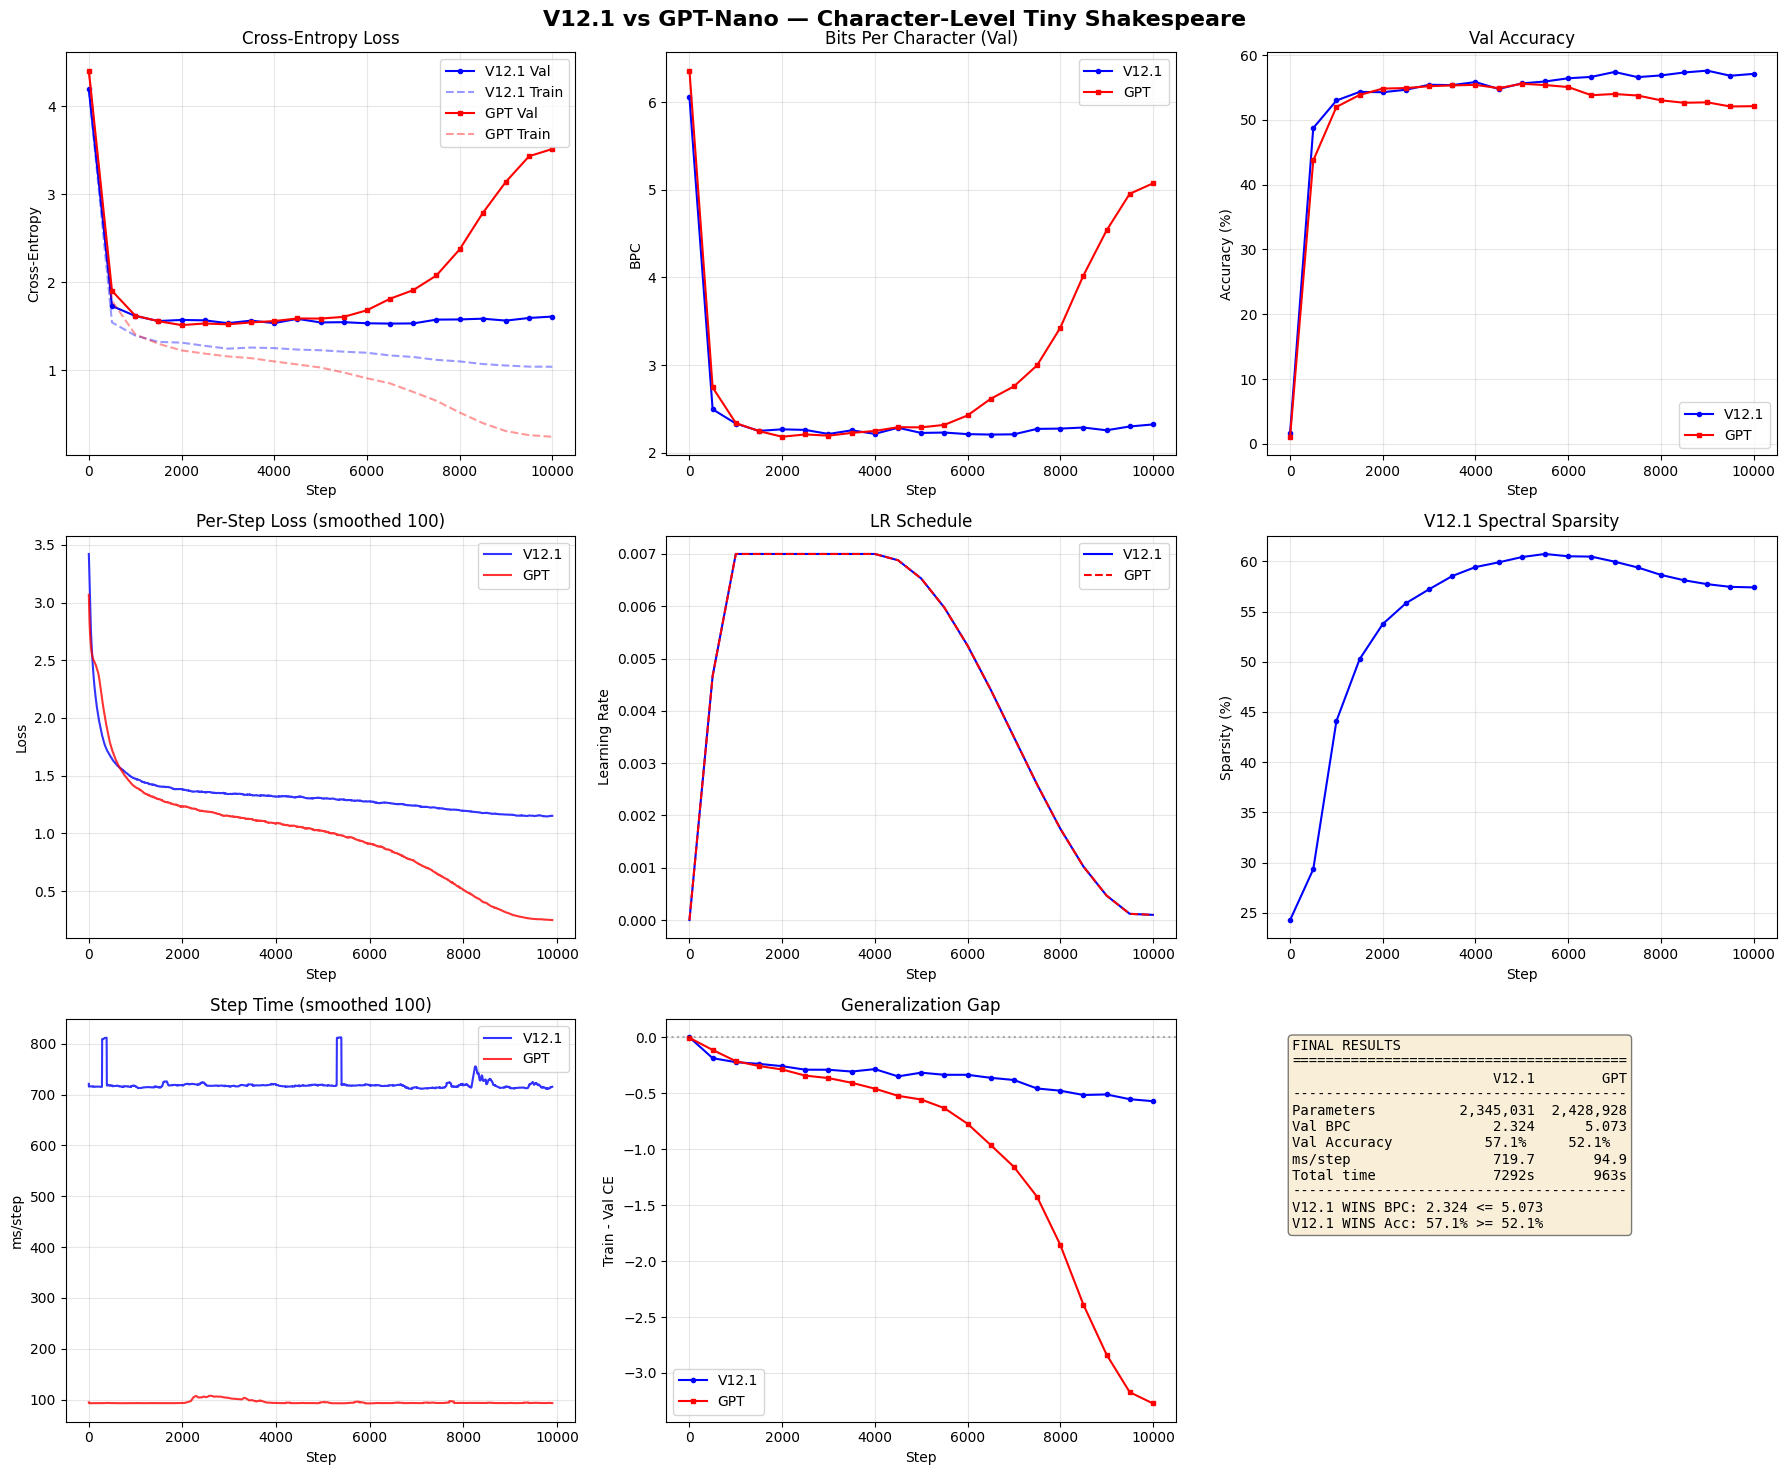

Saved: v12_1_vs_gpt.png


In [15]:
# -- Side-by-side comparison ------------------------------------------------

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('V12.1 vs GPT-Nano — Character-Level Tiny Shakespeare', fontsize=16, fontweight='bold')

# Row 1: Loss curves
ax = axes[0, 0]
ax.plot(v12_history['step'], v12_history['val_ce'], 'b-o', label='V12.1 Val', markersize=3)
ax.plot(v12_history['step'], v12_history['train_ce'], 'b--', alpha=0.4, label='V12.1 Train')
ax.plot(gpt_history['step'], gpt_history['val_ce'], 'r-s', label='GPT Val', markersize=3)
ax.plot(gpt_history['step'], gpt_history['train_ce'], 'r--', alpha=0.4, label='GPT Train')
ax.set_xlabel('Step'); ax.set_ylabel('Cross-Entropy')
ax.set_title('Cross-Entropy Loss'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(v12_history['step'], v12_history['val_bpc'], 'b-o', label='V12.1', markersize=3)
ax.plot(gpt_history['step'], gpt_history['val_bpc'], 'r-s', label='GPT', markersize=3)
ax.set_xlabel('Step'); ax.set_ylabel('BPC')
ax.set_title('Bits Per Character (Val)'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 2]
ax.plot(v12_history['step'], [a*100 for a in v12_history['val_acc']], 'b-o', label='V12.1', markersize=3)
ax.plot(gpt_history['step'], [a*100 for a in gpt_history['val_acc']], 'r-s', label='GPT', markersize=3)
ax.set_xlabel('Step'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Val Accuracy'); ax.legend(); ax.grid(True, alpha=0.3)

# Row 2: Training dynamics
ax = axes[1, 0]
window = 100
if len(v12_history['per_step_loss']) > window:
    v12_smooth = np.convolve(v12_history['per_step_loss'], np.ones(window)/window, mode='valid')
    ax.plot(range(len(v12_smooth)), v12_smooth, 'b-', label='V12.1', alpha=0.8)
if len(gpt_history['per_step_loss']) > window:
    gpt_smooth = np.convolve(gpt_history['per_step_loss'], np.ones(window)/window, mode='valid')
    ax.plot(range(len(gpt_smooth)), gpt_smooth, 'r-', label='GPT', alpha=0.8)
ax.set_xlabel('Step'); ax.set_ylabel('Loss')
ax.set_title(f'Per-Step Loss (smoothed {window})'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(v12_history['step'], v12_history['lr'], 'b-', label='V12.1')
ax.plot(gpt_history['step'], gpt_history['lr'], 'r--', label='GPT')
ax.set_xlabel('Step'); ax.set_ylabel('Learning Rate')
ax.set_title('LR Schedule'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 2]
if any(s > 0 for s in v12_history['sparsity']):
    ax.plot(v12_history['step'], [s*100 for s in v12_history['sparsity']], 'b-o', markersize=3)
    ax.set_xlabel('Step'); ax.set_ylabel('Sparsity (%)')
    ax.set_title('V12.1 Spectral Sparsity'); ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, 'No sparsity data', ha='center', va='center', transform=ax.transAxes)

# Row 3: Speed and generalization
ax = axes[2, 0]
if len(v12_history['step_times']) > window:
    v12_times = np.convolve([t*1000 for t in v12_history['step_times']], np.ones(window)/window, mode='valid')
    ax.plot(range(len(v12_times)), v12_times, 'b-', label='V12.1', alpha=0.8)
if len(gpt_history['step_times']) > window:
    gpt_times = np.convolve([t*1000 for t in gpt_history['step_times']], np.ones(window)/window, mode='valid')
    ax.plot(range(len(gpt_times)), gpt_times, 'r-', label='GPT', alpha=0.8)
ax.set_xlabel('Step'); ax.set_ylabel('ms/step')
ax.set_title(f'Step Time (smoothed {window})'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2, 1]
v12_gap = [t - v for t, v in zip(v12_history['train_ce'], v12_history['val_ce'])]
gpt_gap = [t - v for t, v in zip(gpt_history['train_ce'], gpt_history['val_ce'])]
ax.plot(v12_history['step'], v12_gap, 'b-o', label='V12.1', markersize=3)
ax.plot(gpt_history['step'], gpt_gap, 'r-s', label='GPT', markersize=3)
ax.axhline(y=0, color='k', linestyle=':', alpha=0.3)
ax.set_xlabel('Step'); ax.set_ylabel('Train - Val CE')
ax.set_title('Generalization Gap'); ax.legend(); ax.grid(True, alpha=0.3)

# Summary table
ax = axes[2, 2]
ax.axis('off')
v12_bpc = v12_history['val_bpc'][-1]
gpt_bpc = gpt_history['val_bpc'][-1]
v12_acc = v12_history['val_acc'][-1]
gpt_acc = gpt_history['val_acc'][-1]
v12_ms = v12_history['avg_step_ms']
gpt_ms = gpt_history['avg_step_ms']

summary = (
    f"FINAL RESULTS\n"
    f"{'='*40}\n"
    f"{'':18s} {'V12.1':>10s} {'GPT':>10s}\n"
    f"{'-'*40}\n"
    f"{'Parameters':18s} {n_params:>10,} {gpt_params:>10,}\n"
    f"{'Val BPC':18s} {v12_bpc:>10.3f} {gpt_bpc:>10.3f}\n"
    f"{'Val Accuracy':18s} {v12_acc:>9.1%} {gpt_acc:>9.1%}\n"
    f"{'ms/step':18s} {v12_ms:>10.1f} {gpt_ms:>10.1f}\n"
    f"{'Total time':18s} {v12_history['total_time']:>9.0f}s {gpt_history['total_time']:>9.0f}s\n"
    f"{'-'*40}\n"
)
if v12_bpc <= gpt_bpc:
    summary += f"V12.1 WINS BPC: {v12_bpc:.3f} <= {gpt_bpc:.3f}\n"
else:
    summary += f"V12.1 gap: +{v12_bpc-gpt_bpc:.3f} BPC\n"
if v12_acc >= gpt_acc:
    summary += f"V12.1 WINS Acc: {v12_acc:.1%} >= {gpt_acc:.1%}"
else:
    summary += f"V12.1 gap: {v12_acc-gpt_acc:+.1%} accuracy"

ax.text(0.05, 0.95, summary, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('v12_1_vs_gpt.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: v12_1_vs_gpt.png")

## Diagnostics

In [16]:
# -- V12.1 Diagnostics ------------------------------------------------------

@torch.no_grad()
def v12_diagnostics(model, cfg):
    """Diagnostic analysis of V12.1 internals."""
    model.eval()
    batch = get_batch(val_data, cfg)

    # Embedding sparsity
    spectral_x = model.embedding(batch)
    emb_sparsity = (spectral_x.abs() < 1e-6).float().mean().item()
    print(f"Embedding spectral sparsity: {emb_sparsity:.1%}")

    # Per-block analysis
    for i, block in enumerate(model.blocks):
        spectral_x = block(spectral_x)
        spatial = spectral_to_spatial(spectral_x, cfg)
        spec = spatial_to_spectral(spatial, cfg)
        blk_sparsity = (spec.abs() < 1e-6).float().mean().item()

        # Gate value
        gate = torch.sigmoid(block.res_gate).item()

        # Memory atom statistics
        atoms = block.memory.get_spatial_atoms()  # (K, A, sd)
        atom_norms = atoms.norm(dim=-1).mean().item()

        print(f"Block {i+1}: sparsity={blk_sparsity:.1%}, gate={gate:.3f}, atom_norm={atom_norms:.3f}")

    # Dictionary coherence per block
    print("\nDictionary coherence (lower = more orthogonal):")
    for i, blk in enumerate(model.blocks):
        dcl = 0.
        for dr, di in zip(blk.memory.dict_real, blk.memory.dict_imag):
            atoms = torch.fft.ifft(torch.complex(dr, di), dim=-1).real
            An = F.normalize(atoms, dim=-1)
            g = An @ An.T
            dcl += (g - torch.eye(g.size(0), device=g.device)).pow(2).mean().item()
        dcl /= cfg.n_subbundles
        print(f"  Block {i+1}: DCL = {dcl:.4f}")

    model.train()

v12_diagnostics(model, config)

Embedding spectral sparsity: 68.8%
Block 1: sparsity=67.7%, gate=0.145, atom_norm=1.000
Block 2: sparsity=66.4%, gate=0.251, atom_norm=1.000
Block 3: sparsity=63.2%, gate=0.228, atom_norm=1.000
Block 4: sparsity=60.6%, gate=0.317, atom_norm=1.000
Block 5: sparsity=59.0%, gate=0.183, atom_norm=1.000
Block 6: sparsity=57.4%, gate=0.258, atom_norm=1.000

Dictionary coherence (lower = more orthogonal):
  Block 1: DCL = 0.0000
  Block 2: DCL = 0.0000
  Block 3: DCL = 0.0000
  Block 4: DCL = 0.0000
  Block 5: DCL = 0.0000
  Block 6: DCL = 0.0000


In [17]:
# -- Text Generation --------------------------------------------------------

@torch.no_grad()
def generate_text(model, prompt, cfg, max_new=200, temperature=0.8, is_gpt=False):
    model.eval()
    ids = torch.tensor([stoi[c] for c in prompt], dtype=torch.long, device=device).unsqueeze(0)
    for _ in range(max_new):
        ctx = ids[:, -cfg.seq_len:]
        logits, _ = model(ctx)
        logits = logits[:, -1, :] / temperature
        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, 1)
        ids = torch.cat([ids, next_id], dim=1)
    return "".join(itos[i.item()] for i in ids[0])

prompts = ["ROMEO:\n", "To be or not to ", "The king ", "O, "]
for prompt in prompts:
    print(f"\nPrompt: {repr(prompt)}")
    print(f"  V12.1: {generate_text(model, prompt, config)[len(prompt):len(prompt)+100]}")
    print(f"  GPT:   {generate_text(gpt_model, prompt, config, is_gpt=True)[len(prompt):len(prompt)+100]}")


Prompt: 'ROMEO:\n'
  V12.1: 
NHuAsRhD IWIALT::

WPAARRIISA::

SLaYt: 
I
 Hsapmeenntt,,  mtyh abboovne. 
TFheer'esst  sytmrpeidn 
  GPT:   

CGORREELNOE:G
eWaAr diosnuulr edreesm;e rtehl dreesd aogth,t

ITni oank  ooff its,,  nnoor,,  ntoi

Prompt: 'To be or not to '
  V12.1:  msaevlee  aansdwreadr;

HMoyu naemde,d  nwiet!h ,t hgoaonl ysot-
-Ia kanudg,e riigshse  tsetn eoyls
  GPT:    gtraen: 
lBoutts  hwehraelsd oyfeusl afrto ntoeusn-,-

PRRIICCHHAARRDD::

WHrOORT BoomllioM,:  tthh

Prompt: 'The king '
  V12.1: 
iMs ttoe  atn otnheerr,. 
AWlhl etv eyveyr ?'
 
CFAIRDdI:N
:T hwoiulldy. 
I
sReeansc,e died  tBhaap
  GPT:   ,b eoxpfeorr ;t
aWlasi,n gtiuvlietdy ,t adniegs:;  II  atm
otuhr ictoar dtreidceesss ,m oaftf uanndo

Prompt: 'O, '
  V12.1:  sIi rkella naomn earsl?y
 HCeorcse,s ,M yaorr  hmoosote raeg-ubptraatbelreenst.o
uTnReYloyu,s  maad
  GPT:    nwoiulmd  bweelt -u
p'ptatsr,e rgeanreyr,  afntoen dhielvde.r

YSO:R
,S Ii rwairn  mmyy  tmreotr  b


## Summary

### V12.1: Streamlined Spectral Sparsity

**Core changes from V12:**
- SpatialMLP adds the nonlinear channel mixing V12 lacked (GPT's FFN equivalent)
- Langevin 5->2 steps: 60% less settler compute, non-negotiables preserved
- Simplified memory: dot-product Hopfield replaces 8 MLP routers (Ramsauer 2021)
- 4->6 blocks: more representational depth
- 10K steps: V12 was still improving at 5K

**V12 Non-Negotiables (all preserved):**
1. Sparse in spectral, dense only transiently in spatial
2. Field reconstruction IS the inverse Fourier transform
3. Langevin starts from the reconstructed (IFFT) field
4. Context warps the spectral metric (D and A are context-dependent)
5. Spectral proximal at every Langevin step
6. Subbundles are independent spectral channels
7. No pairwise token attention

**Block flow:**
```
sparse spectral -> IFFT -> SSM context -> spectral transport ->
IFFT (field reconstruction) -> 2-step Hopfield settling (spectral proximal each) ->
SpatialMLP -> gated residual -> FFT + re-sparsify -> sparse spectral
```